O objetivo dessa análise é **identificar os períodos os quais o índice IBOV teve um comportamento fora do normal**, a fim de compreender possíveis momentos em que o Index tracking poderá ter dificuldades em replicar o índice.

Na nossa análise serão utilizadas as **variações do retorno em valores percentuais**, ao invés de valores absolutos. Isso porque um dia de -5% é um choque severo independentemente de o índice estar em 70 mil ou 130 mil pontos. Assim, todos os dias ficam na mesma escala, o que torna a comparação entre períodos diferentes justa e significativa.



Importando as bibliotecas necessárias

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Definindo uma variável para o índice Ibovespa

In [4]:
indice_ibov = pd.read_csv('/content/drive/MyDrive/bootcamp FINOR/ibov_indice_retornos.csv', parse_dates=['Date'])
indice_ibov = indice_ibov.sort_values('Date').reset_index(drop=True)
print(indice_ibov.head(10))

        Date    ^BVSP  Variação_Diária_%
0 2018-01-02  77891.0                NaN
1 2018-01-03  77995.0           0.133520
2 2018-01-04  78647.0           0.835951
3 2018-01-05  79071.0           0.539118
4 2018-01-08  79379.0           0.389523
5 2018-01-09  78864.0          -0.648786
6 2018-01-10  78201.0          -0.840688
7 2018-01-11  79365.0           1.488472
8 2018-01-12  79349.0          -0.020160
9 2018-01-15  79752.0           0.507883


Obtendo a estatística descritiva, a fim de entender com que dados estamos lidando.

In [5]:
print(indice_ibov.info())
print(indice_ibov.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1818 entries, 0 to 1817
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               1818 non-null   datetime64[ns]
 1   ^BVSP              1818 non-null   float64       
 2   Variação_Diária_%  1817 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 42.7 KB
None
                                Date          ^BVSP  Variação_Diária_%
count                           1818    1818.000000        1817.000000
mean   2021-09-02 12:34:03.564356608  108074.155116           0.041927
min              2018-01-02 00:00:00   63570.000000         -14.779679
25%              2019-10-31 06:00:00   97943.750000          -0.722239
50%              2021-09-04 12:00:00  109932.000000           0.053002
75%              2023-07-03 18:00:00  120065.000000           0.830314
max              2025-04-30 00:00:00  137344.000000      

Criando um **boxplot** dos retornos diários do Ibovespa, para identificar possíveis outliers

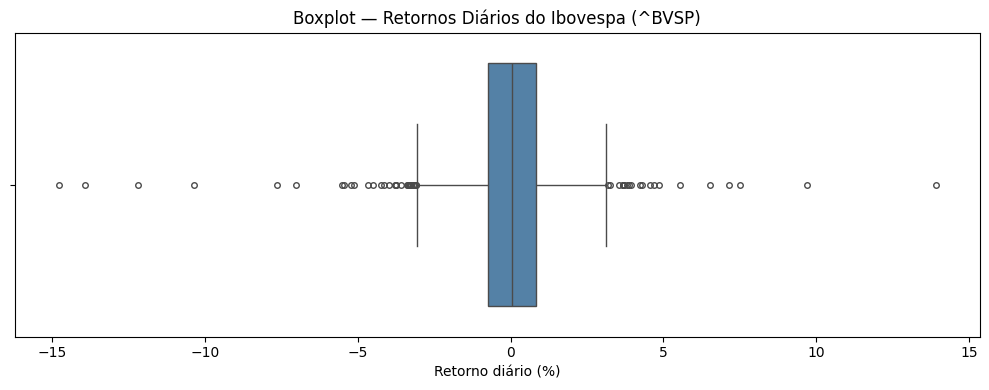

In [6]:
plt.figure(figsize=(10, 4))
sns.boxplot(
    x=indice_ibov['Variação_Diária_%'],
    color='steelblue',
    flierprops=dict(marker='o', color='red', markersize=4)
)
plt.title('Boxplot — Retornos Diários do Ibovespa (^BVSP)')
plt.xlabel('Retorno diário (%)')
plt.tight_layout()
plt.show()

Informações obtidas através da análise do gráfico.

1.   Os quartils 1 e 3 estão concentrados próximos ao zero, o que indica um comportamento padrão dos retornos na maior parte do tempo.
2.   Existem mais outliers negativos do que positivos, o que ilustra que o índice passou por varios períodos turbulentos.
3. É possível notar um Cluster (agrupamento) entre -3% até -8% e 3% até 5%.  Isso significa que retornos anormais não foram eventos isolados, mas uma *crise prolongada.*






Com o objetivo de identificar os períodos os quais ocorreram os outliers e seus respectivos valores, vamos definir o limite inferior e superior.

In [7]:
Q1 = indice_ibov['Variação_Diária_%'].quantile(0.25)
Q3 = indice_ibov['Variação_Diária_%'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f'Q1:               {Q1:.2f}%')
print(f'Q3:               {Q3:.2f}%')
print(f'IQR:              {IQR:.2f}%')
print(f'Limite inferior:  {limite_inferior:.2f}%')
print(f'Limite superior:  {limite_superior:.2f}%')

Q1:               -0.72%
Q3:               0.83%
IQR:              1.55%
Limite inferior:  -3.05%
Limite superior:  3.16%


Após descobrir que o **limite inferior vale -3.05% e o limite superior 3.16%,** agora podemos descobrir em quais momentos aconteceram os outliers e as variações diárias correspondentes.

In [8]:
outliers = indice_ibov[
    (indice_ibov['Variação_Diária_%'] < limite_inferior) |
    (indice_ibov['Variação_Diária_%'] > limite_superior)
].copy()

print(f'Total de outliers encontrados: {len(outliers)}')
print(outliers[['Date', '^BVSP', 'Variação_Diária_%']].to_string(index=False))

Total de outliers encontrados: 51
      Date    ^BVSP  Variação_Diária_%
2018-01-24  83680.0           3.720965
2018-02-14  83543.0           3.268273
2018-05-17  83622.0          -3.368501
2018-05-28  75356.0          -4.489341
2018-10-02  81612.0           3.800366
2018-10-08  86084.0           4.569860
2018-10-30  86886.0           3.686289
2019-01-02  91012.0           3.555702
2019-02-06  94636.0          -3.738137
2019-03-22  93735.0          -3.095245
2019-03-27  91903.0          -3.571616
2020-01-27 114482.0          -3.289518
2020-02-26 105718.0          -7.004689
2020-03-05 102233.0          -4.654741
2020-03-06  97997.0          -4.143476
2020-03-09  86067.0         -12.173842
2020-03-10  92214.0           7.142110
2020-03-11  85171.0          -7.637669
2020-03-12  72583.0         -14.779679
2020-03-13  82678.0          13.908215
2020-03-16  71168.0         -13.921479
2020-03-17  74617.0           4.846279
2020-03-18  66895.0         -10.348848
2020-03-23  63570.0          -

In [9]:
outliers['Ano'] = outliers['Date'].dt.year
print(outliers.groupby('Ano')['Variação_Diária_%'].count())

Ano
2018     7
2019     4
2020    27
2021     7
2022     3
2023     2
2024     1
Name: Variação_Diária_%, dtype: int64


In [10]:
maiores_altas = outliers.nlargest(10, 'Variação_Diária_%')[['Date', '^BVSP', 'Variação_Diária_%']]
maiores_quedas = outliers.nsmallest(10, 'Variação_Diária_%')[['Date', '^BVSP', 'Variação_Diária_%']]

print('Top 10 maiores altas:')
print(maiores_altas.to_string(index=False))

print('\nTop 10 maiores quedas:')
print(maiores_quedas.to_string(index=False))

Top 10 maiores altas:
      Date    ^BVSP  Variação_Diária_%
2020-03-13  82678.0          13.908215
2020-03-24  69729.0           9.688532
2020-03-25  74956.0           7.496164
2020-03-10  92214.0           7.142110
2020-04-06  74073.0           6.521614
2022-10-03 116134.0           5.540864
2020-03-17  74617.0           4.846279
2020-05-18  81194.0           4.689454
2018-10-08  86084.0           4.569860
2023-04-11 106214.0           4.287804

Top 10 maiores quedas:
      Date    ^BVSP  Variação_Diária_%
2020-03-12  72583.0         -14.779679
2020-03-16  71168.0         -13.921479
2020-03-09  86067.0         -12.173842
2020-03-18  66895.0         -10.348848
2020-03-11  85171.0          -7.637669
2020-02-26 105718.0          -7.004689
2020-03-27  73429.0          -5.508944
2020-04-24  75331.0          -5.449776
2020-03-23  63570.0          -5.217015
2021-02-22 112668.0          -5.120086


##Análise dos períodos e conclusão

* A maior parte dos outliers encontrados pertencem ao período de 2020, mais especificamente no mês de março, que condiz com o auge da pandemia de Covid-19 no Brasil.

* Também vale ressaltar que em 2018 apareceram outliers, os quais se relacionam a uma possível guerra entre EUA e China e instabilidades políticas no Brasil, visto que era ano eleitoral.

* Os demais anos apresentam outliers mais isolados, o que indica que pequenas crises ou incertezas não perduraram por tanto tempo.

Portanto, conclui-se que a forte **presença de clusters** no período da pandemia (2020) representa o **maior desafio para a replicação precisa do índice**, uma vez que retornos anormais consecutivos dificultam o rebalanceamento da carteira e aumentam o risco de tracking error.